# **(Co_Risk_analyzer)**

## Objectives

# ETL & Analysis: risk hypotheses from clinical features
This notebook performs an ETL pipeline, feature engineering, and visualizations using only pandas and numpy. It evaluates these hypotheses:
- High BMI is associated with higher `Heart_Attack_Risk_Percentage`.
- A positive `Family_History_CVD` is associated with higher `Heart_Attack_Risk_Percentage`.
- High BMI and `Family_History_CVD` together show higher heart attack risk than either factor alone.
- Current `Smoking_Status` is associated with higher `Heart_Attack_Risk_Percentage`.
- High `Systolic_BP` (>= 140) is associated with higher `Mortality_Risk_Percentage`.
- Low `Physical_Activity_Level` is associated with higher `Heart_Attack_Risk_Percentage` and `Mortality_Risk_Percentage`.
- `Diabetes` present is associated with higher `Mortality_Risk_Percentage`.
- Low `Medication_Adherence_Percentage` is associated with higher `Mortality_Risk_Percentage`.


---

## Data Source

The primary dataset for this project is Patient comorbidity risk assessment data collected from Kaggle intended for research purposes https://www.kaggle.com/datasets/velvetcrystal/patient-comorbidity-risk-assessment-dataset


In [54]:
# Importing necessary python packages for ETL And visualization purpose.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
print('imports ok')

imports ok


* To make the notebook work on different devices, we first identify the current working folder and then change it to its parent folder so that file paths are easier to access consistently..

# Change working directory

* We access the current directory with os.getcwd()
We want to make the parent of the current directory the new current directory
* Function find_project_root sets the current directory by applying for loop and if conditions to avoid ris of re-runs setting inappropiate dirctory path.
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [55]:
import os
from pathlib import Path


def find_project_root(start=None):
    if start is None:
        start = Path.cwd().resolve()

    candidates = []
    for candidate in [start, *start.parents]:
        candidates.append(candidate)

    # Also try the project folder directly if it exists on this machine.
    known_project = Path(r"C:/Users/User/Desktop/Data Analysis with AI Course/Code Institute/vscode-projects/CoRiskAnalyzer/CoRiskAnalyzer")
    if known_project.exists():
        candidates.append(known_project)

    seen = set()
    for candidate in candidates:
        if candidate in seen:
            continue
        seen.add(candidate)

        if (candidate / "Datasets").exists():
            return candidate

        if candidate.name.lower() == "jupyter_notebooks" and (candidate.parent / "Datasets").exists():
            return candidate.parent

    return start


project_dir = find_project_root()
os.chdir(project_dir)
print("Project directory:", project_dir)
current_dir = os.getcwd()
print("Current directory:", current_dir)


Project directory: C:\Users\User\Desktop\Data Analysis with AI Course\Code Institute\vscode-projects\CoRiskAnalyzer\CoRiskAnalyzer
Current directory: C:\Users\User\Desktop\Data Analysis with AI Course\Code Institute\vscode-projects\CoRiskAnalyzer\CoRiskAnalyzer


# Loading the data to a Data Framework by reading from csv file.

In [56]:
df = pd.read_csv(current_dir + '/Datasets/Patient_Comorbidity_Risk_Assessment_Dataset.csv')
print('Dataframe loaded successfully')

Dataframe loaded successfully


# overview of rows and columns of the data
# Gettingt the dtypes of columns which can be numerical or catogorical

In [57]:
# displaying the first 5 rows
df.head()

,Patient_ID,Age,Gender,BMI,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Diabetes,Hypertension,Chronic_Kidney_Disease,Liver_Disease,Cholesterol_Level,Systolic_BP,Diastolic_BP,Resting_Heart_Rate,HbA1c,Family_History_CVD,Medication_Adherence_Percentage,Heart_Attack_Risk_Percentage,Mortality_Risk_Percentage
0,PT100001,63,Female,18.8,Former,NaN,High,0,0,0,0,170.0,120.0,80.0,89.0,4.9,0,74.0,1.1,4.5
1,PT100002,41,Male,35.1,Never,NaN,NaN,0,0,0,0,174.0,131.0,72.0,81.0,NaN,0,100.0,7.8,7.3
2,PT100003,70,Female,34.6,Never,Low,NaN,0,0,0,0,221.0,135.0,77.0,77.0,5.6,0,88.0,5.4,7.5
3,PT100004,73,Male,39.8,Never,Low,Moderate,0,1,0,0,168.0,165.0,102.0,78.0,5.6,0,93.0,19.7,25.1
4,PT100005,27,Male,33.1,Current,High,Low,0,0,0,0,147.0,NaN,70.0,88.0,6.1,0,100.0,11.6,6.3


---

In [58]:
#discovering the shape of the dataset and the column names
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient_ID                       10000 non-null  str    
 1   Age                              10000 non-null  int64  
 2   Gender                           10000 non-null  str    
 3   BMI                              9338 non-null   float64
 4   Smoking_Status                   9385 non-null   str    
 5   Alcohol_Consumption              6066 non-null   str    
 6   Physical_Activity_Level          9262 non-null   str    
 7   Diabetes                         10000 non-null  int64  
 8   Hypertension                     10000 non-null  int64  
 9   Chronic_Kidney_Disease           10000 non-null  int64  
 10  Liver_Disease                    10000 non-null  int64  
 11  Cholesterol_Level                9423 non-null   float64
 12  Systolic_BP                   

In [59]:
# view all columns in data set
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'BMI', 'Smoking_Status',
       'Alcohol_Consumption', 'Physical_Activity_Level', 'Diabetes',
       'Hypertension', 'Chronic_Kidney_Disease', 'Liver_Disease',
       'Cholesterol_Level', 'Systolic_BP', 'Diastolic_BP',
       'Resting_Heart_Rate', 'HbA1c', 'Family_History_CVD',
       'Medication_Adherence_Percentage', 'Heart_Attack_Risk_Percentage',
       'Mortality_Risk_Percentage'],
      dtype='str')

In [60]:
# check data types of each column
df.dtypes

Patient_ID                             str
Age                                  int64
Gender                                 str
BMI                                float64
Smoking_Status                         str
Alcohol_Consumption                    str
Physical_Activity_Level                str
Diabetes                             int64
Hypertension                         int64
Chronic_Kidney_Disease               int64
Liver_Disease                        int64
Cholesterol_Level                  float64
Systolic_BP                        float64
Diastolic_BP                       float64
Resting_Heart_Rate                 float64
HbA1c                              float64
Family_History_CVD                   int64
Medication_Adherence_Percentage    float64
Heart_Attack_Risk_Percentage       float64
Mortality_Risk_Percentage          float64
dtype: object

In [61]:
# check the summary statistics of the dataset
df.describe()

,Age,BMI,Diabetes,Hypertension,Chronic_Kidney_Disease,Liver_Disease,Cholesterol_Level,Systolic_BP,Diastolic_BP,Resting_Heart_Rate,HbA1c,Family_History_CVD,Medication_Adherence_Percentage,Heart_Attack_Risk_Percentage,Mortality_Risk_Percentage
count,10000.000000,9338.000000,10000.00000,10000.000000,10000.000000,10000.000000,9423.000000,9429.000000,9429.000000,9302.000000,9462.000000,10000.000000,9234.000000,10000.000000,10000.000000
mean,57.809800,27.640983,0.08260,0.203300,0.052000,0.061100,191.853019,121.892247,76.682681,76.876478,5.576675,0.247500,79.818064,18.269930,12.031570
std,15.831307,5.452933,0.27529,0.402474,0.222038,0.239526,28.586452,15.563679,9.503391,10.264479,0.845903,0.431581,13.149790,13.775983,12.022517
min,18.000000,15.000000,0.00000,0.000000,0.000000,0.000000,100.000000,80.000000,50.000000,40.000000,4.000000,0.000000,29.000000,0.000000,0.000000
25%,47.000000,23.900000,0.00000,0.000000,0.000000,0.000000,172.000000,111.000000,70.000000,70.000000,5.200000,0.000000,71.000000,7.600000,3.000000
50%,58.000000,27.600000,0.00000,0.000000,0.000000,0.000000,192.000000,121.000000,76.000000,77.000000,5.400000,0.000000,80.000000,15.900000,8.900000
75%,68.000000,31.300000,0.00000,0.000000,0.000000,0.000000,211.000000,132.000000,83.000000,84.000000,5.700000,0.000000,90.000000,26.400000,17.300000
max,95.000000,47.800000,1.00000,1.000000,1.000000,1.000000,315.000000,188.000000,112.000000,116.000000,11.800000,1.000000,100.000000,86.400000,85.700000


---

# Section 1.2 Transforming the raw, Uncleaned data : Data Cleaning & Pre-processing

This Section will clean the data by identifying the missing values, duplicates and invalid values and refining them to shape the dataframe ready for anlysis.
checks to perform suitable dtypes for each attribute is available for further analysis.

In [62]:
# view all columns names in dataset
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'BMI', 'Smoking_Status',
       'Alcohol_Consumption', 'Physical_Activity_Level', 'Diabetes',
       'Hypertension', 'Chronic_Kidney_Disease', 'Liver_Disease',
       'Cholesterol_Level', 'Systolic_BP', 'Diastolic_BP',
       'Resting_Heart_Rate', 'HbA1c', 'Family_History_CVD',
       'Medication_Adherence_Percentage', 'Heart_Attack_Risk_Percentage',
       'Mortality_Risk_Percentage'],
      dtype='str')

In [63]:
#getting the count of missing values in each column
df.isnull().sum()

Patient_ID                            0
Age                                   0
Gender                                0
BMI                                 662
Smoking_Status                      615
Alcohol_Consumption                3934
Physical_Activity_Level             738
Diabetes                              0
Hypertension                          0
Chronic_Kidney_Disease                0
Liver_Disease                         0
Cholesterol_Level                   577
Systolic_BP                         571
Diastolic_BP                        571
Resting_Heart_Rate                  698
HbA1c                               538
Family_History_CVD                    0
Medication_Adherence_Percentage     766
Heart_Attack_Risk_Percentage          0
Mortality_Risk_Percentage             0
dtype: int64

In [64]:
# check data types of each column
df.dtypes

Patient_ID                             str
Age                                  int64
Gender                                 str
BMI                                float64
Smoking_Status                         str
Alcohol_Consumption                    str
Physical_Activity_Level                str
Diabetes                             int64
Hypertension                         int64
Chronic_Kidney_Disease               int64
Liver_Disease                        int64
Cholesterol_Level                  float64
Systolic_BP                        float64
Diastolic_BP                       float64
Resting_Heart_Rate                 float64
HbA1c                              float64
Family_History_CVD                   int64
Medication_Adherence_Percentage    float64
Heart_Attack_Risk_Percentage       float64
Mortality_Risk_Percentage          float64
dtype: object

In [65]:
# Identifying the missing values in the dataset
df.isnull().sum()

Patient_ID                            0
Age                                   0
Gender                                0
BMI                                 662
Smoking_Status                      615
Alcohol_Consumption                3934
Physical_Activity_Level             738
Diabetes                              0
Hypertension                          0
Chronic_Kidney_Disease                0
Liver_Disease                         0
Cholesterol_Level                   577
Systolic_BP                         571
Diastolic_BP                        571
Resting_Heart_Rate                  698
HbA1c                               538
Family_History_CVD                    0
Medication_Adherence_Percentage     766
Heart_Attack_Risk_Percentage          0
Mortality_Risk_Percentage             0
dtype: int64

## # ETL: basic cleaning and type conversions for the dataset for Hypothesis testing and visualization purposes.

#Addressing the Numeric columns

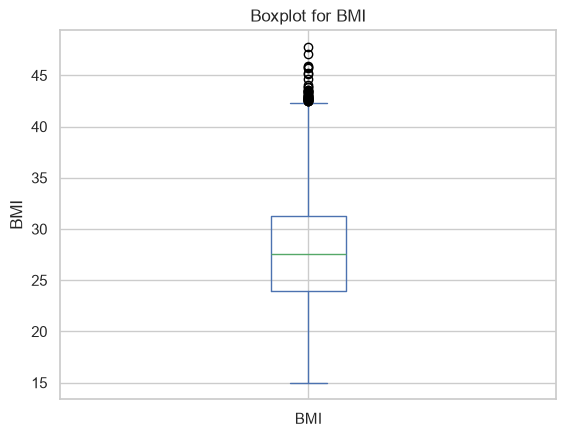

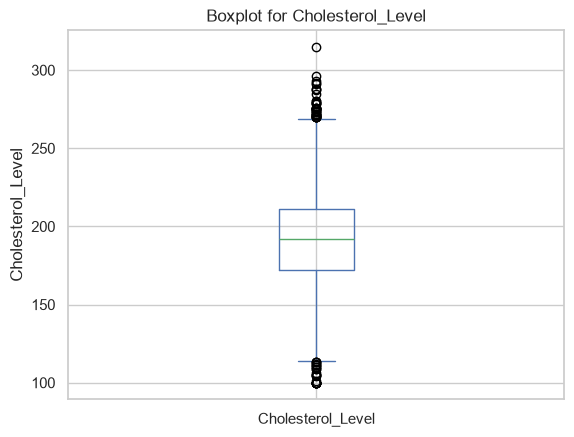

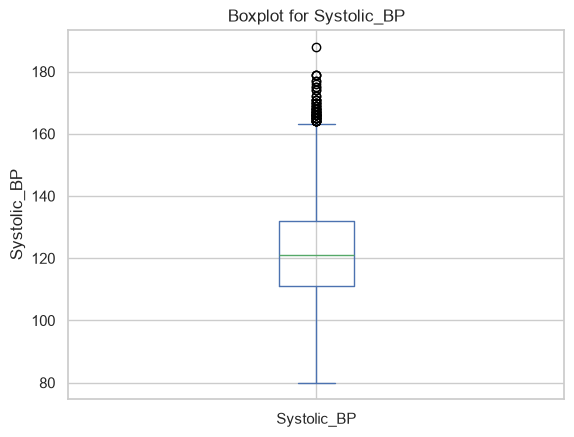

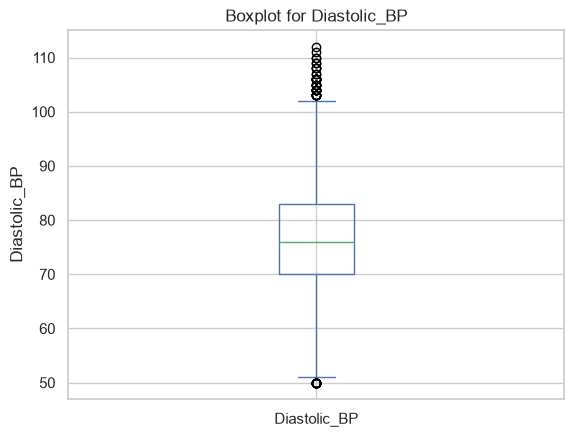

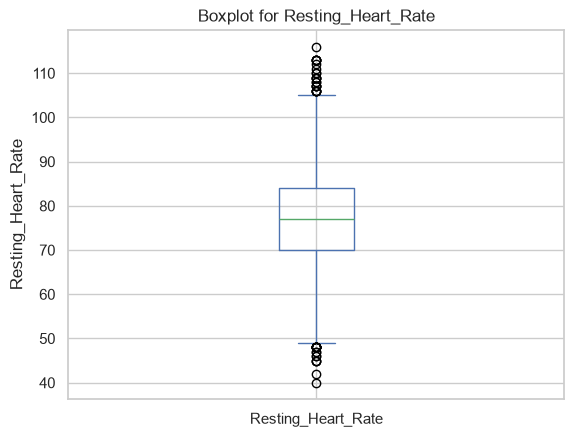

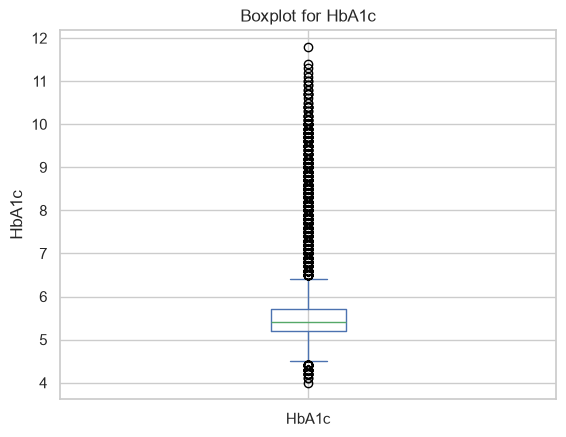

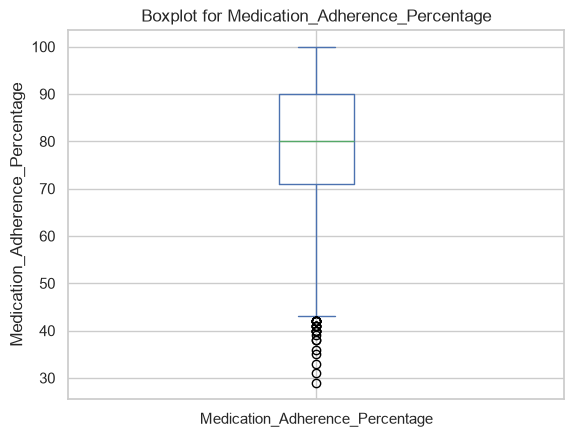

,Patient_ID,Age,Gender,BMI,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Diabetes,Hypertension,Chronic_Kidney_Disease,Liver_Disease,Cholesterol_Level,Systolic_BP,Diastolic_BP,Resting_Heart_Rate,HbA1c,Family_History_CVD,Medication_Adherence_Percentage,Heart_Attack_Risk_Percentage,Mortality_Risk_Percentage
0,PT100001,63,Female,18.8,Former,NaN,High,0,0,0,0,170.0,120.0,80.0,89.0,4.9,0,74.0,1.1,4.5
1,PT100002,41,Male,35.1,Never,NaN,NaN,0,0,0,0,174.0,131.0,72.0,81.0,5.4,0,100.0,7.8,7.3
2,PT100003,70,Female,34.6,Never,Low,NaN,0,0,0,0,221.0,135.0,77.0,77.0,5.6,0,88.0,5.4,7.5
3,PT100004,73,Male,39.8,Never,Low,Moderate,0,1,0,0,168.0,165.0,102.0,78.0,5.6,0,93.0,19.7,25.1
4,PT100005,27,Male,33.1,Current,High,Low,0,0,0,0,147.0,121.0,70.0,88.0,6.1,0,100.0,11.6,6.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,PT109996,84,Male,27.6,Never,NaN,High,0,0,0,0,192.0,125.0,80.0,49.0,5.5,0,65.0,8.4,14.9
9996,PT109997,57,Male,18.1,Current,Low,Moderate,0,0,0,0,153.0,112.0,72.0,82.0,4.7,1,87.0,25.4,9.0
9997,PT109998,59,Female,15.9,Never,NaN,Low,0,0,0,0,168.0,117.0,62.0,84.0,5.1,1,72.0,10.2,0.0
9998,PT109999,76,Female,31.6,NaN,NaN,NaN,0,0,0,0,231.0,120.0,94.0,82.0,5.4,0,79.0,22.4,11.0


In [66]:
# converting the data types of the columns to appropriate types and filling missing values for numeric columns with mean of the column
num_cols = ['BMI','Cholesterol_Level', 'Systolic_BP', 'Diastolic_BP','Resting_Heart_Rate','HbA1c','Medication_Adherence_Percentage']

#check the outliers in the numeric columns using boxplots
for c in num_cols:
    df[c].plot(kind='box')
    plt.title(f'Boxplot for {c}')
    plt.ylabel(c)
    plt.show()

# As the number of outliers is high, we will use the median to fill the missing values for the numeric columns. The median is less affected by outliers and will provide a more robust estimate of the central tendency of the data.
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df.fillna({c: df[c].median() for c in num_cols}, inplace=True)


# Addressing the catogorical columns

In [67]:
# Smoking status fill and simplifying the missing values to 'Unknown'
if 'Smoking_Status' in df.columns:
    df['Smoking_Status'] = df['Smoking_Status'].fillna('Unknown')

# Physical Activity Level fill and simplifying the missing values to'Unknown'
if 'Physical_Activity_Level' in df.columns:
    df['Physical_Activity_Level'] = df['Physical_Activity_Level'].fillna('Unknown')

# Create comorbidity_count for each patient by counting the number of comorbidities they have. We will consider the following columns as comorbidities: 'Diabetes', 'Hypertension', 'Heart_Disease', 'Chronic_Kidney_Disease', 'Chronic_Lung_Disease', 'Cancer', 'Stroke', 'Obesity', 'Depression', 'Anxiety'. We will create a new column called 'comorbidity_count' that will contain the count of comorbidities for each patient.
comorbidity_cols = ['Diabetes', 'Hypertension', 'Chronic_Kidney_Disease', 'Liver_Disease']
df['comorbidity_count'] = df[comorbidity_cols].fillna(0).astype(int).sum(axis=1)

# Create risk flags
df['SBP_high'] = (df['Systolic_BP'] > 140).astype(int)
df['Low_Adherence'] = (df['Medication_Adherence_Percentage'] < 80).astype(int)
df.head()

,Patient_ID,Age,Gender,BMI,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Diabetes,Hypertension,Chronic_Kidney_Disease,...,Diastolic_BP,Resting_Heart_Rate,HbA1c,Family_History_CVD,Medication_Adherence_Percentage,Heart_Attack_Risk_Percentage,Mortality_Risk_Percentage,comorbidity_count,SBP_high,Low_Adherence
0,PT100001,63,Female,18.8,Former,NaN,High,0,0,0,...,80.0,89.0,4.9,0,74.0,1.1,4.5,0,0,1
1,PT100002,41,Male,35.1,Never,NaN,Unknown,0,0,0,...,72.0,81.0,5.4,0,100.0,7.8,7.3,0,0,0
2,PT100003,70,Female,34.6,Never,Low,Unknown,0,0,0,...,77.0,77.0,5.6,0,88.0,5.4,7.5,0,0,0
3,PT100004,73,Male,39.8,Never,Low,Moderate,0,1,0,...,102.0,78.0,5.6,0,93.0,19.7,25.1,1,1,0
4,PT100005,27,Male,33.1,Current,High,Low,0,0,0,...,70.0,88.0,6.1,0,100.0,11.6,6.3,0,0,0


## Featue Engineering 

In [68]:
# Feature engineering BMI categories and obesity flag
# creating BMI categories column based on WHO classification representing the BMI ranges for underweight, normal weight, overweight and obese. We will create a new column called 'BMI_Category' that will contain the BMI category for each patient based on their BMI value. We will also create a new column called 'Obesity_Flag' that will contain a binary value indicating whether the patient is obese or not based on their BMI value.
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 25:
        return 'Normal weight'
    elif 25 <= bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'
df['BMI_Category'] = df['BMI'].apply(bmi_category)
df['Obesity_Flag'] = (df['BMI_Category'] == 'Obese').astype(int)
# creating a new column Obese_x_FH with intraction of Obesity_Flag and Family_History_CVD to identify patients who are obese and have a family history of disease. We will create a new column called 'Obese_x_FH' that will contain a binary value indicating whether the patient is obese and has a family history of disease or not.
df['Obesity_x_FH'] = df['Obesity_Flag'] * df['Family_History_CVD']

#Simple encoding for smoking (current vs Other) with introducing 'Smoking_current' with binary values for current smokers and non-current smokers. We will create a new column called 'Smoking_current' that will contain a binary value indicating whether the patient is a current smoker or not based on their smoking status.
df['Smoking_current'] = (df['Smoking_Status'].str.lower() == 'current').astype(int)
df[['BMI','BMI_Category','Obesity_Flag','Family_History_CVD','Obesity_x_FH']].head()

,BMI,BMI_Category,Obesity_Flag,Family_History_CVD,Obesity_x_FH
0,18.8,Normal weight,0,0,0
1,35.1,Obese,1,0,0
2,34.6,Obese,1,0,0
3,39.8,Obese,1,0,0
4,33.1,Obese,1,0,0


---

## Outputs

* An Output file model_results.csv is generated after ETL and Feture engineering process for hypothesis analysis and Outcomes /Reports.


# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.